# What is the System Usability Scale (SUS)?

The System Usability Scale (SUS) is a short, reliable measuring instrument for capturing the usability of interactive systems. It was developed by John Brooke (Digital Equipment) in the 1980s and has since been widely used in usability evaluations, benchmarking, and product decisions.

## Essentials in Brief:

- The SUS consists of 10 questions with a 5-point Likert scale (1 = Strongly disagree, 5 = Strongly agree).
- The questions are alternately positively and negatively worded. To ensure that after evaluation a higher value always means better usability, the raw responses are first converted to values from 0-4 and then summed up (→ see below).
- Although short, the SUS provides robust, comparable usability metrics and is useful for evaluations, trend measurements, and benchmarking between versions/products.
- This notebook implements common interpretation guidelines (e.g., Sauro & Lewis), which categorize means into categories like Unacceptable, Marginal, OK, Good, Excellent.

### What does "Normalization" mean here?

Normalization in this notebook means: converting the raw responses (1-5) so that all items have the same direction (higher = better) and are on a common scale of 0-4. This makes the responses comparable and allows the 10 values to be summed afterward.

- For positive items (Q1, Q3, Q5, Q7, Q9): normalized value = response - 1
  - Example: Response 4 → 4 - 1 = 3 (scale 0..4).
- For negative items (Q2, Q4, Q6, Q8, Q10): normalized value = 5 - response
  - Example: Response 4 → 5 - 4 = 1 (scale 0..4).

After normalization, each item has a value between 0 and 4. The 10 values are added → sum 0-40. This sum is multiplied by 2.5 to get the common 0-100 scale (e.g., sum 31 → 31 × 2.5 = 77.5).

Short schematic overview (raw → normalized):

- Positive item: 1 → 0, 2 → 1, 3 → 2, 4 → 3, 5 → 4 (formula: response - 1)
- Negative item: 1 → 4, 2 → 3, 3 → 2, 4 → 1, 5 → 0 (formula: 5 - response)

Short calculation example (manual):

Assumed responses (Q1..Q10): [3, 2, 4, 1, 5, 2, 4, 2, 5, 3]

- Positive items (Q1,Q3,Q5,Q7,Q9): 3→2, 4→3, 5→4, 4→3, 5→4 → sum = 16
- Negative items (Q2,Q4,Q6,Q8,Q10): 2→3, 1→4, 2→3, 2→3, 3→2 → sum = 15
- Total sum = 16 + 15 = 31 → SUS = 31 × 2.5 = 77.5 → Interpretation: Good (B).

Note on robustness (as handled in the notebook):

- Invalid or non-numeric entries are converted to NaN in Pandas (pd.to_numeric with errors='coerce').
- Rows with missing responses in the 10 SUS items are removed by default (dropna), to keep the calculation clean.
- Alternatively, "imputation" could be used — that is, estimating missing item values with plausible replacement values (e.g., Pro-Rating: scaling up the answered items, or Multiple Imputation to account for uncertainty). This option is not implemented here.

Sources & further reading (selection):

- [Brooke, J. (1995). SUS: A quick and dirty usability scale.](https://www.researchgate.net/publication/228593520_SUS_A_quick_and_dirty_usability_scale) (Origin of the instrument).
- [Sauro, J., & Lewis, J. R. (2016). Quantifying the User Experience: Practical Statistics for User Research.](https://scispace.com/pdf/quantifying-the-user-experience-c0m621ep8r.pdf) (Interpretation & Statistics).
- [Bangor, Kortum & Miller (2008). An empirical evaluation of the System Usability Scale.](https://2024.sci-hub.se/6915/a99810f9ec5ad833799508989b8431fc/10.1080@10447310802205776.pdf) (Empirical validation and interpretation hints).

Note on using this notebook: It loads a Google Forms/CSV export, maps columns (Q1..Q10), calculates SUS values per participant, and shows statistical metrics as well as an interpretive visualization.

## The 10 SUS Questions

Responses are given on a scale from 1 (Strongly disagree) to 5 (Strongly agree). Questions 2, 4, 6, 8, and 10 are negatively worded (inverted during normalization).

1. I think that I would like to use this system regularly.
2. I found the system unnecessarily complex.
3. I thought the system was easy to use.
4. I think that I would need the support of a technical person to be able to use this system.
5. I found the various functions in this system were well integrated.
6. I thought there was too much inconsistency in this system.
7. I would imagine that most people would learn to use this system very quickly.
8. I found the system very cumbersome to use.
9. I felt very confident using the system.
10. I needed to learn a lot of things before I could get going with this system.

Note: Negative items (2,4,6,8,10) are inverted during evaluation: normalized value = 5 - response. Positive items: normalized value = response - 1.

In [1]:
# Helper table: How raw responses (1-5) are normalized?
import pandas as pd
raw = [1,2,3,4,5]
pos = [r - 1 for r in raw]  # positive items: response - 1
neg = [5 - r for r in raw]  # negative items: 5 - response
df_norm = pd.DataFrame({'Raw': raw, 'Positive (Response-1)': pos, 'Negative (5-Response)': neg})
print('Normalization table (Raw -> normalized):')
print(df_norm.to_string(index=False))

Normalization table (Raw -> normalized):
 Raw  Positive (Response-1)  Negative (5-Response)
   1                      0                      4
   2                      1                      3
   3                      2                      2
   4                      3                      1
   5                      4                      0


In [2]:
import re
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn-Stil für akademisch ansprechende Grafiken setzen
sns.set_theme(style="whitegrid")

In [3]:
# Display options: show complete lists/tables in outputs (no truncation)
import numpy as np
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth', None)
np.set_printoptions(threshold=np.inf)
print("Note: Pandas/Numpy display options set: full lists/tables will be shown.")

Note: Pandas/Numpy display options set: full lists/tables will be shown.


In [4]:
# Define the filename of your export
# (Google Forms often exports as a .csv file of the linked sheet)
DATEINAME = 'sus_google_forms_export.csv'

# Load function with guard clauses
path = Path(DATEINAME)
if not path.exists():
    print(f"ERROR: The file '{DATEINAME}' was not found in the directory: {path.resolve()}")
    raise SystemExit(1)

try:
    df = pd.read_csv(path)
except Exception as e:
    print(f"An unexpected error occurred while loading: {e}")
    raise

# --- START: More robust automatic column cleaning ---

def map_column_names(col_name_raw):
    """
    Attempts to create a clean designation from various column name variants, e.g., 'Q1', 'Q10', or 'Proband_ID'.
    This function is more robust to formats like 'Q1:', 'Q1 - Question', or ' q1 '.
    """

    col_name = str(col_name_raw).strip()
    col_name_lower = col_name.lower()

    # Catch participant ID variants (e.g., 'Proband_ID' or 'Proband ID')
    if re.search(r'proband[_\s]?id', col_name, re.IGNORECASE):
        return 'Proband_ID'

    # Keyword-based mapping for long Google Forms question texts (fallback)
    keyword_map = {
        'regelmäßig zu nutzen': 'Q1',
        'regelmaessig zu nutzen': 'Q1',  # alternative spelling without umlaut
        'unnötig komplex': 'Q2',
        'unnoetig komplex': 'Q2',
        'einfach zu nutzen': 'Q3',
        'technischen support': 'Q4',
        'gut integriert': 'Q5',
        'zu viele inkonsistenzen': 'Q6',
        'schnell zu beherrschen': 'Q7',
        'sehr umständlich': 'Q8',
        'sehr umstaendlich': 'Q8',
        'sehr sicher gefühlt': 'Q9',
        'sehr sicher gefuehlt': 'Q9',
        'menge dinge lernen': 'Q10',
        'lernen': 'Q10'  # last-resort for variants
    }
    for kw, target in keyword_map.items():
        if kw in col_name_lower:
            return target

    # Match for Q1..Q10 (accepts 'Q1:', 'Q1 -', 'Q1)', 'q10' etc.)
    m = re.search(r'\bq\s*[:\)\.-]*\s*(10|[1-9])\b', col_name, re.IGNORECASE)
    if m:
        return f"Q{m.group(1)}"

    # If no rule applies, keep original name
    return col_name

# Apply the mapping
df_clean = df.rename(columns=map_column_names)

# If no Proband_ID column is present, generate one automatically
if 'Proband_ID' not in df_clean.columns:
    df_clean['Proband_ID'] = [f"P{str(i+1).zfill(3)}" for i in range(len(df_clean))]
    print("Note: 'Proband_ID' was not present and was automatically generated as P001..")

# --- END: Column cleaning ---

# Verification of results
print("--- Analysis of column names ---")
print("Original column names (full):")
print(df.columns.tolist())
print("Cleaned column names (full):")
print(df_clean.columns.tolist())

required_cols = ['Proband_ID', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10']
missing_cols = [col for col in required_cols if col not in df_clean.columns]
if missing_cols:
    print(f"\nWARNING: The following columns are missing after cleaning: {missing_cols}")
    print("Please check the mapping rules or the CSV headers.")
else:
    print("\nSTATUS: All 10 SUS items and the Proband_ID have been successfully mapped.")

Note: 'Proband_ID' was not present and was automatically generated as P001..
--- Analysis of column names ---
Original column names (full):
['Zeitstempel', 'Wie bewerten Sie die Usability von MC-Test-App? [Ich kann mir sehr gut vorstellen, das System regelmäßig zu nutzen.]', 'Wie bewerten Sie die Usability von MC-Test-App? [Ich empfinde das System als unnötig komplex.]', 'Wie bewerten Sie die Usability von MC-Test-App? [Ich empfinde das System als einfach zu nutzen.]', 'Wie bewerten Sie die Usability von MC-Test-App? [Ich denke, dass ich technischen Support brauchen würde, um das System zu nutzen.]', 'Wie bewerten Sie die Usability von MC-Test-App? [Ich finde, dass die verschiedenen Funktionen des Systems gut integriert sind.]', 'Wie bewerten Sie die Usability von MC-Test-App? [Ich finde, dass es im System zu viele Inkonsistenzen gibt.]', 'Wie bewerten Sie die Usability von MC-Test-App? [Ich kann mir vorstellen, dass die meisten Leute das System schnell zu beherrschen lernen.]', 'Wie b

In [5]:
# Short validation check
print("\n--- Short validation check ---")
print("Columns in df_clean:")
print(df_clean.columns.tolist())

required_cols = ['Proband_ID','Q1','Q2','Q3','Q4','Q5','Q6','Q7','Q8','Q9','Q10']
missing = [c for c in required_cols if c not in df_clean.columns]
if missing:
    print("ERROR: Missing columns:", missing)
else:
    print("OK: All required columns are present.")

print(f"Number of rows in df_clean: {len(df_clean)}")


--- Short validation check ---
Columns in df_clean:
['Zeitstempel', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Proband_ID']
OK: All required columns are present.
Number of rows in df_clean: 20


In [6]:
# We use the cleaned DataFrame 'df_clean' from cell 2
df_calc = df_clean.copy()

# 1. Lists of positive (odd) and negative (even) items
positive_cols = ['Q1', 'Q3', 'Q5', 'Q7', 'Q9']
negative_cols = ['Q2', 'Q4', 'Q6', 'Q8', 'Q10']
required_qs = positive_cols + negative_cols

# 2. Ensure that the required columns are present
missing_qs = [c for c in required_qs if c not in df_calc.columns]
if missing_qs:
    raise SystemExit(f"Missing Q-columns for calculation: {missing_qs}")

# 3. Type conversion (robust) - non-convertible values become NaN
df_calc[required_qs] = df_calc[required_qs].apply(pd.to_numeric, errors='coerce')

# 4. Check value range (expected: 1..5). Values outside are reported
out_of_range = ((df_calc[required_qs] < 1) | (df_calc[required_qs] > 5)).any(axis=1)
if out_of_range.any():
    n_bad = int(out_of_range.sum())
    print(f"WARNING: {n_bad} rows contain values outside the expected range 1..5. These rows will still be processed (NaN/Drop), please check.")

# 5. Missing values: leave decision here, we drop rows with at least one missing Q-value
n_before = len(df_calc)
df_calc = df_calc.dropna(subset=required_qs).reset_index(drop=True)
n_after = len(df_calc)
print(f"Rows before cleaning: {n_before}, after dropping NaNs in Qs: {n_after} (removed: {n_before - n_after})")

# 6. Normalization (vectorized)
# Positive items: value - 1; Negative items: 5 - value
df_calc[positive_cols] = df_calc[positive_cols] - 1
df_calc[negative_cols] = 5 - df_calc[negative_cols]

# 7. Sum formation and multiplication
normalized_cols = positive_cols + negative_cols
df_calc['SUS_Summe_0_40'] = df_calc[normalized_cols].sum(axis=1)
df_calc['SUS_Score_0_100'] = df_calc['SUS_Summe_0_40'] * 2.5

print("\nCalculation completed. Data including SUS score (full):")
print(df_calc[['Proband_ID', 'SUS_Summe_0_40', 'SUS_Score_0_100']].to_string(index=False))

Rows before cleaning: 20, after dropping NaNs in Qs: 20 (removed: 0)

Calculation completed. Data including SUS score (full):
Proband_ID  SUS_Summe_0_40  SUS_Score_0_100
      P001              29             72.5
      P002              29             72.5
      P003              33             82.5
      P004              33             82.5
      P005              19             47.5
      P006              28             70.0
      P007              31             77.5
      P008              36             90.0
      P009              31             77.5
      P010              22             55.0
      P011              31             77.5
      P012              18             45.0
      P013              33             82.5
      P014              22             55.0
      P015              19             47.5
      P016              16             40.0
      P017              31             77.5
      P018              32             80.0
      P019              38            

In [7]:
print("--- Statistical overall evaluation (All participants) ---")

# We now use the calculated DataFrame 'df_calc'
if 'SUS_Score_0_100' not in df_calc.columns:
    raise SystemExit('SUS_Score_0_100 missing in DataFrame; please run the calculation cell first.')

sus_stats = df_calc['SUS_Score_0_100'].describe()
mean_score = float(sus_stats['mean'])
std_dev = float(sus_stats['std'])
n_count = int(sus_stats['count'])
median_score = float(sus_stats['50%'])

# 95% confidence interval for the mean (approx. z=1.96)
import math
se = std_dev / math.sqrt(n_count) if n_count > 0 else float('nan')
ci_lower = mean_score - 1.96 * se
ci_upper = mean_score + 1.96 * se

print(sus_stats)
print("\n--- Summary (Dashboard) ---")
print(f"Number of participants (n):     {n_count}")
print(f"SUS Score (Mean):    {mean_score:.2f} (95% CI: {ci_lower:.2f} - {ci_upper:.2f})")
print(f"Standard deviation (SD):   {std_dev:.2f}")
print(f"Median:                    {median_score:.2f}")
print(f"Minimum score:           {sus_stats['min']:.2f}")
print(f"Maximum score:           {sus_stats['max']:.2f}")

# Interpretation of the mean (Sauro-Lewis)
if mean_score < 51:
    interpretation = "Unacceptable (F)"
elif mean_score < 68:
    interpretation = "Marginal (D)"
elif mean_score < 74:
    interpretation = "OK (C)"
elif mean_score < 80.3:
    interpretation = "Good (B)"
else:
    interpretation = "Excellent (A)"

print(f"\nInterpretation (Mean): {interpretation}")

--- Statistical overall evaluation (All participants) ---
count    20.000000
mean     70.375000
std      16.085197
min      40.000000
25%      55.000000
50%      77.500000
75%      80.625000
max      95.000000
Name: SUS_Score_0_100, dtype: float64

--- Summary (Dashboard) ---
Number of participants (n):     20
SUS Score (Mean):    70.38 (95% CI: 63.33 - 77.42)
Standard deviation (SD):   16.09
Median:                    77.50
Minimum score:           40.00
Maximum score:           95.00

Interpretation (Mean): OK (C)


In [8]:
# Interpretation: Add label/grade for SUS scores and generate report
def interpret_sus(score):
    """Returns (Label, Grade) based on conventional thresholds (Sauro/Lewis)."""
    if score < 51:
        return ('Unacceptable (F)', 'F')
    elif score < 68:
        return ('Marginal (D)', 'D')
    elif score < 74:
        return ('OK (C)', 'C')
    elif score < 80.3:
        return ('Good (B)', 'B')
    else:
        return ('Excellent (A)', 'A')

# Apply to individual scores (if column exists)
if 'SUS_Score_0_100' in df_calc.columns:
    df_calc['SUS_Label'] = df_calc['SUS_Score_0_100'].apply(lambda s: interpret_sus(s)[0])
    df_calc['SUS_Grade'] = df_calc['SUS_Score_0_100'].apply(lambda s: interpret_sus(s)[1])

    print("--- SUS Interpretation & Labeling ---")
    print(df_calc['SUS_Label'].value_counts(dropna=False).to_string())
    mean_label, mean_grade = interpret_sus(mean_score)
    print(f"\nMean: {mean_score:.2f} -> {mean_label} (Grade: {mean_grade})")
    print(f"n = {n_count}, SD = {std_dev:.2f}, 95% CI = [{ci_lower:.2f}, {ci_upper:.2f}]")

    # Complete list of data with label
    print("\nExample (all participants):")
    display_cols = ['Proband_ID','SUS_Summe_0_40','SUS_Score_0_100','SUS_Label','SUS_Grade']
    print(df_calc[display_cols].to_string(index=False))
else:
    print("SUS_Score_0_100 missing — run the calculation cell first.")

--- SUS Interpretation & Labeling ---
SUS_Label
Good (B)            6
Excellent (A)       5
Unacceptable (F)    4
OK (C)              3
Marginal (D)        2

Mean: 70.38 -> OK (C) (Grade: C)
n = 20, SD = 16.09, 95% CI = [63.33, 77.42]

Example (all participants):
Proband_ID  SUS_Summe_0_40  SUS_Score_0_100        SUS_Label SUS_Grade
      P001              29             72.5           OK (C)         C
      P002              29             72.5           OK (C)         C
      P003              33             82.5    Excellent (A)         A
      P004              33             82.5    Excellent (A)         A
      P005              19             47.5 Unacceptable (F)         F
      P006              28             70.0           OK (C)         C
      P007              31             77.5         Good (B)         B
      P008              36             90.0    Excellent (A)         A
      P009              31             77.5         Good (B)         B
      P010              2

Creating improved distribution diagram with interpretation bands...


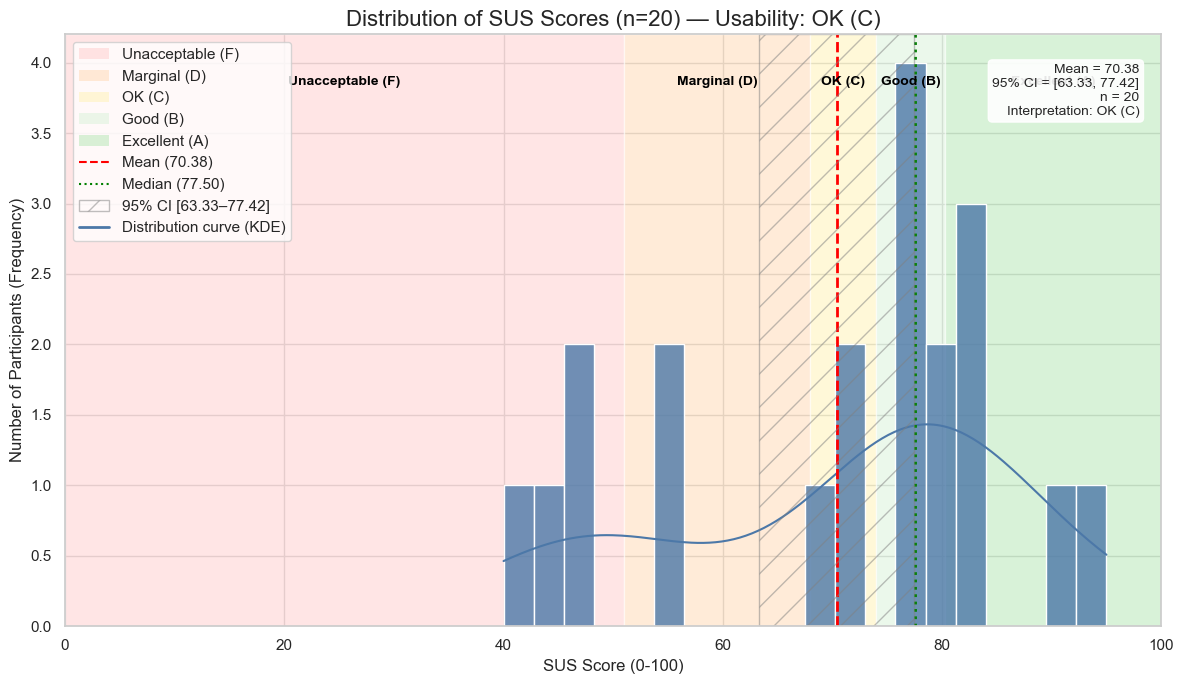

In [9]:
print("Creating improved distribution diagram with interpretation bands...")
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(12, 7))
# Definition of interpretation ranges (Start, End, Color, Label)
bands = [
    (0, 51, '#ffcccc', 'Unacceptable (F)'),
    (51, 68, '#ffd9b3', 'Marginal (D)'),
    (68, 74, '#fff2b3', 'OK (C)'),
    (74, 80.3, '#d9f2d9', 'Good (B)'),
    (80.3, 100, '#b3e6b3', 'Excellent (A)')
]
# Draw background bands
for start, end, color, label in bands:
    ax.axvspan(start, end, facecolor=color, alpha=0.5)

# Draw histogram + KDE over the bands (on axis ax)
viz = sns.histplot(data=df_calc, x='SUS_Score_0_100', bins=20, kde=True, alpha=0.8, ax=ax, color='#4c78a8')

# Now determine y-limits for text positioning
ymin, ymax = ax.get_ylim()
y_text = ymax * 0.92
for start, end, color, label in bands:
    xpos = (start + end) / 2
    ax.text(xpos, y_text, label, ha='center', va='center', fontsize=10, color='black', weight='semibold')

# Draw vertical lines for mean (red) and median (green)
ax.axvline(mean_score, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_score:.2f})')
ax.axvline(median_score, color='green', linestyle=':', linewidth=2, label=f'Median ({median_score:.2f})')

# Axis labels and title
ax.set_title(f'Distribution of SUS Scores (n={n_count}) — Usability: {mean_label}', fontsize=16)
ax.set_xlabel('SUS Score (0-100)')
ax.set_ylabel('Number of Participants (Frequency)')
ax.set_xlim(0, 100)

# Legend with color bands and lines
patch_handles = [mpatches.Patch(facecolor=color, edgecolor='none', alpha=0.5, label=label) for (_, _, color, label) in bands]
ci_patch = mpatches.Patch(facecolor='none', edgecolor='gray', hatch='/', alpha=0.5, label=f'95% CI [{ci_lower:.2f}–{ci_upper:.2f}]')
kde_handle = Line2D([0], [0], color=viz.get_lines()[0].get_color(), lw=2, label='Distribution curve (KDE)') # NEW: More understandable text
line_handles = [Line2D([0], [0], color='red', linestyle='--', label=f'Mean ({mean_score:.2f})'),
                Line2D([0], [0], color='green', linestyle=':', label=f'Median ({median_score:.2f})')]
ax.legend(handles=patch_handles + line_handles + [ci_patch, kde_handle], loc='upper left')

# NEW: Draw CI range as lighter, less dense hatching
ax.axvspan(ci_lower, ci_upper, facecolor='none', edgecolor='gray', hatch='/', alpha=0.5, zorder=2)

# Additional: Interpretation of the mean in textbox (now at the end to be on top of everything)
textbox = f"Mean = {mean_score:.2f}\n95% CI = [{ci_lower:.2f}, {ci_upper:.2f}]\nn = {n_count}\nInterpretation: {mean_label}"
ax.text(0.98, 0.95, textbox, transform=ax.transAxes, fontsize=10, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9), zorder=3)

plt.tight_layout()
plt.savefig('sus_score_distribution_interpreted.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Calculate skewness of the SUS scores distribution
skewness = df_calc['SUS_Score_0_100'].skew()
print(f"Skewness of SUS Scores: {skewness:.3f}")
if skewness > 0:
    print("The distribution is right-skewed (positive skewness).")
elif skewness < 0:
    print("The distribution is left-skewed (negative skewness).")
else:
    print("The distribution is symmetric (skewness ≈ 0).")

Skewness of SUS Scores: -0.625
The distribution is left-skewed (negative skewness).
